In [ ]:
# ==== Paths & Imports (robust) ====
import os, sys, random, math, time, json
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


def add_repo_root(pkg_name="kaggle"):
    """
    Walk up from CWD to find a directory that contains `pkg_name/__init__.py`,
    then prepend that directory to sys.path and return it.
    """
    here = Path(os.getcwd()).resolve()
    for p in [here] + list(here.parents):
        if (p / pkg_name / "__init__.py").exists():
            if str(p) not in sys.path:
                sys.path.insert(0, str(p))
            return str(p)
    raise FileNotFoundError(
        f"Could not find a repository root containing {pkg_name}/__init__.py "
        f"starting from {here}"
    )


ROOT = add_repo_root("kaggle")
print("Project root added to sys.path ->", ROOT)
print("First 3 sys.path entries:", sys.path[:3])

from kaggle.scr.dataset import SegDataset, get_transforms
from kaggle.scr.model import build_model
from kaggle.scr.loss import combined_loss
from kaggle.scr.train_utils import train_one_epoch, validate, calculate_iou

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
device

Project root added to sys.path -> /homes/nfs/ben/project/AI-pruning-project
First 3 sys.path entries: ['/homes/nfs/ben/project/AI-pruning-project', '/homes/nfs/ben/miniconda3/envs/kaggle/lib/python312.zip', '/homes/nfs/ben/miniconda3/envs/kaggle/lib/python3.12']
Python: 3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 18:56:27) [GCC 11.2.0]
Torch: 2.5.1+cu121
CUDA available: True


'cuda'

In [2]:
# ==== Reproducibility ====
SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
print("Seed set to", SEED)

Seed set to 42


In [3]:
# ==== Config ====
DATA_ROOT = os.path.join(ROOT, "kaggle", "data")
TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train", "imgs")
TRAIN_MASK_DIR = os.path.join(DATA_ROOT, "train", "masks")
TEST_IMG_DIR = os.path.join(DATA_ROOT, "test", "imgs")  # inference 用

assert os.path.exists(TRAIN_IMG_DIR), f"Missing: {TRAIN_IMG_DIR}"
assert os.path.exists(TRAIN_MASK_DIR), f"Missing: {TRAIN_MASK_DIR}"

CFG = {
    "model_name": "Unet++",  # "DeepLabV3Plus" | "Unet++" | "FPN"
    "encoder": "efficientnet-b5",  # 可改 "resnet50" / "resnet101" / "efficientnet-b4"
    "num_classes": 16,
    "pretrained": True,
    "epochs": 40,
    "batch_size": 8,
    "lr": 1e-4,
    "weight_decay": 1e-5,
    "num_workers": 2,
    "use_amp": True,  # 混合精度（有 CUDA 才會啟用）
    "train_resize": (576, 576),
    "train_crop": (512, 512),
    "val_size": (512, 512),
    "save_dir": os.path.join(ROOT, "kaggle"),
    "fig_dir": os.path.join(ROOT, "kaggle", "fig"),
}
os.makedirs(CFG["fig_dir"], exist_ok=True)
CFG

{'model_name': 'Unet++',
 'encoder': 'efficientnet-b5',
 'num_classes': 16,
 'pretrained': True,
 'epochs': 40,
 'batch_size': 8,
 'lr': 0.0001,
 'weight_decay': 1e-05,
 'num_workers': 2,
 'use_amp': True,
 'train_resize': (576, 576),
 'train_crop': (512, 512),
 'val_size': (512, 512),
 'save_dir': '/homes/nfs/ben/project/AI-pruning-project/kaggle',
 'fig_dir': '/homes/nfs/ben/project/AI-pruning-project/kaggle/fig'}

In [4]:
# ==== Datasets & Dataloaders ====
from sklearn.model_selection import train_test_split

train_tf = get_transforms("train")
val_tf = get_transforms("val")

all_files = sorted([f for f in os.listdir(TRAIN_IMG_DIR) if f.endswith(".png")])
train_files, val_files = train_test_split(all_files, test_size=0.2, random_state=SEED)


class SplitSegDataset(SegDataset):
    def __init__(self, img_dir, mask_dir=None, transform=None, subset_files=None):
        super().__init__(img_dir, mask_dir, transform)
        if subset_files is not None:
            name_set = set(subset_files)
            self.fnames = [f for f in self.fnames if f in name_set]


train_ds = SplitSegDataset(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_tf, subset_files=train_files
)
val_ds = SplitSegDataset(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=val_tf, subset_files=val_files
)

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    num_workers=CFG["num_workers"],
    pin_memory=True,
)
val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    num_workers=CFG["num_workers"],
    pin_memory=True,
)

print("Train/Val sizes:", len(train_ds), len(val_ds))

# -- Sanity: 看一個 batch --
imgs, masks = next(iter(train_loader))
print(
    "Batch image tensor:", imgs.shape, imgs.dtype, imgs.min().item(), imgs.max().item()
)
print(
    "Batch mask   tensor:",
    masks.shape,
    masks.dtype,
    masks.min().item(),
    masks.max().item(),
)

# -- Sanity: 查看 mask 的 unique（只看第一張） --
import torch

print("One mask uniques:", torch.unique(masks[0]))

Train/Val sizes: 3200 800
Batch image tensor: torch.Size([8, 3, 512, 512]) torch.float32 -2.1179039478302 2.6399998664855957
Batch mask   tensor: torch.Size([8, 512, 512]) torch.int64 0 15
One mask uniques: tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 11, 12, 13, 15])


In [5]:
# ==== Model / Optimizer / Scheduler / AMP ====
model = build_model(
    model_name=CFG["model_name"],
    encoder=CFG["encoder"],
    num_classes=CFG["num_classes"],
    pretrained=CFG["pretrained"],
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"]
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)
scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda" and CFG["use_amp"]))

total_params_m = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model params: {total_params_m:.2f} M")

Model params: 31.91 M


/tmp/ipykernel_5440/2111410283.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda" and CFG["use_amp"]))


In [6]:
# ==== Forward Sanity Check ====
model.eval()
with torch.no_grad():
    x, y = next(iter(train_loader))
    x = x.to(device)
    out = model(x)
print("Forward output shape:", out.shape)  # 期望 [B, num_classes, H, W]


Forward output shape: torch.Size([8, 16, 512, 512])


In [7]:
# ==== Training Loop ====
from tqdm.auto import tqdm

E = CFG["epochs"]
best_iou = -1.0
save_path = os.path.join(CFG["save_dir"], f"{CFG["model_name"]}best_model.pth")

train_losses, val_losses = [], []
train_ious, val_ious = [], []

for epoch in range(E):
    model.train()
    running_loss, running_iou = 0.0, 0.0
    for imgs, masks in tqdm(train_loader, desc=f"Train {epoch+1}/{E}"):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad(set_to_none=True)
        if scaler.is_enabled():
            with torch.cuda.amp.autocast():
                out = model(imgs)
                loss = combined_loss(out, masks)
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            out = model(imgs)
            loss = combined_loss(out, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        running_loss += loss.item()
        running_iou += calculate_iou(out, masks)

    tr_loss = running_loss / len(train_loader)
    tr_iou = running_iou / len(train_loader)
    train_losses.append(tr_loss)
    train_ious.append(tr_iou)

    # ---- validation ----
    model.eval()
    val_loss, val_iou = 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in tqdm(val_loader, desc="Validating"):
            imgs, masks = imgs.to(device), masks.to(device)
            out = model(imgs)
            loss = combined_loss(out, masks)
            val_loss += loss.item()
            val_iou += calculate_iou(out, masks)
    val_loss /= len(val_loader)
    val_iou /= len(val_loader)
    val_losses.append(val_loss)
    val_ious.append(val_iou)

    scheduler.step(epoch + val_loss)  # 或者 scheduler.step() 也可

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), save_path)
        print(
            f"✅ [Epoch {epoch+1}] New best IoU: {best_iou:.4f} -> saved to {save_path}"
        )

    print(
        f"[Epoch {epoch+1:02d}/{E}] "
        f"TrainLoss={tr_loss:.4f}  TrainIoU={tr_iou:.4f} | "
        f"ValLoss={val_loss:.4f}  ValIoU={val_iou:.4f}"
    )

Train 1/40:   0%|          | 0/400 [00:00<?, ?it/s]

/tmp/ipykernel_5440/3359236705.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Validating:   0%|          | 0/100 [00:00<?, ?it/s]

✅ [Epoch 1] New best IoU: 0.1309 -> saved to /homes/nfs/ben/project/AI-pruning-project/kaggle/Unet++best_model.pth
[Epoch 01/40] TrainLoss=1.1817  TrainIoU=0.1000 | ValLoss=0.8672  ValIoU=0.1309


Train 2/40:   0%|          | 0/400 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/100 [00:00<?, ?it/s]

✅ [Epoch 39] New best IoU: 0.4156 -> saved to /homes/nfs/ben/project/AI-pruning-project/kaggle/Unet++best_model.pth
[Epoch 39/40] TrainLoss=0.3787  TrainIoU=0.4084 | ValLoss=0.3526  ValIoU=0.4156


Train 40/40:   0%|          | 0/400 [00:00<?, ?it/s]

Validating:   0%|          | 0/100 [00:00<?, ?it/s]

✅ [Epoch 40] New best IoU: 0.4188 -> saved to /homes/nfs/ben/project/AI-pruning-project/kaggle/Unet++best_model.pth
[Epoch 40/40] TrainLoss=0.3701  TrainIoU=0.4195 | ValLoss=0.3494  ValIoU=0.4188


Saved: /homes/nfs/ben/project/AI-pruning-project/kaggle/fig/training_curves.png


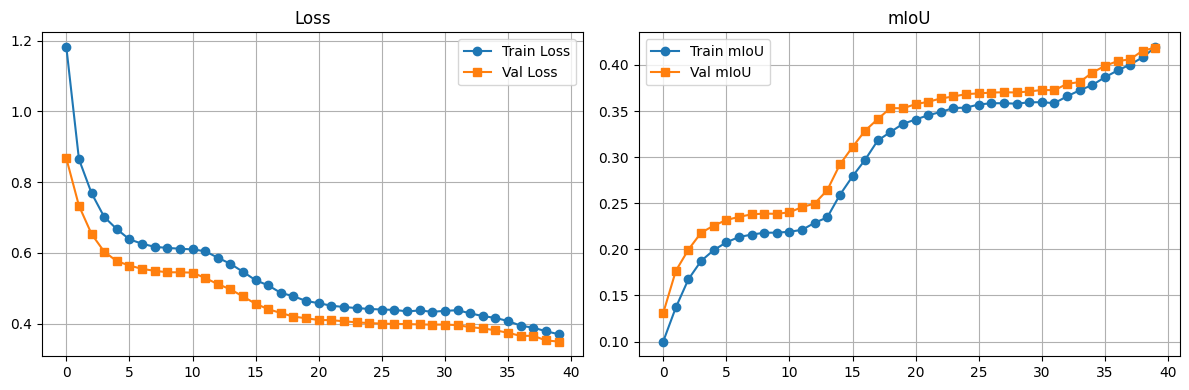

In [8]:
# ==== Plot Curves ====
out_png = os.path.join(CFG["fig_dir"], "training_curves.png")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", marker="o")
plt.plot(val_losses, label="Val Loss", marker="s")
plt.title("Loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_ious, label="Train mIoU", marker="o")
plt.plot(val_ious, label="Val mIoU", marker="s")
plt.title("mIoU")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(out_png, dpi=150, bbox_inches="tight")
print("Saved:", out_png)

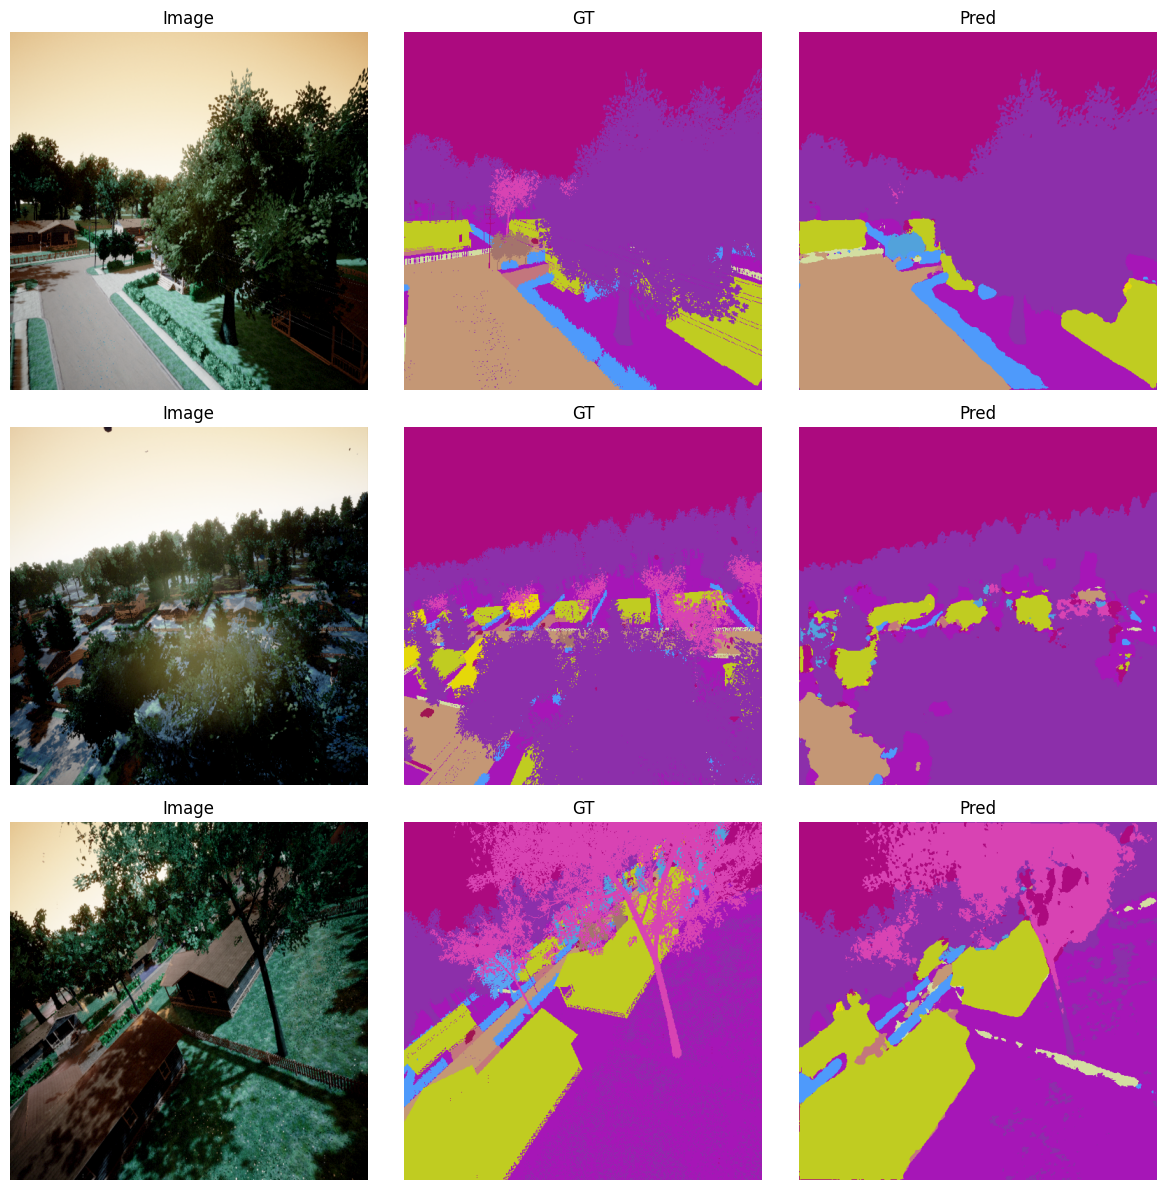

In [9]:
# ==== Qualitative Check: show predictions ====
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt


def colorize_mask(mask, num_classes=16):
    # 隨機但固定的色表（報告時也可改為官方 colormap）
    np.random.seed(0)
    palette = np.random.randint(0, 255, size=(num_classes, 3), dtype=np.uint8)
    h, w = mask.shape
    color = np.zeros((h, w, 3), dtype=np.uint8)
    for c in range(num_classes):
        color[mask == c] = palette[c]
    return color


model.eval()
idxs = np.random.choice(len(val_ds), size=3, replace=False)
plt.figure(figsize=(12, 12))
plot_i = 1
for i in idxs:
    img, gt = val_ds[i]  # 已是 tensor (C,H,W) & (H,W)
    with torch.no_grad():
        pred = model(img.unsqueeze(0).to(device)).argmax(1).squeeze(0).cpu().numpy()
    img_np = img.permute(1, 2, 0).cpu().numpy() * np.array(
        [0.229, 0.224, 0.225]
    ) + np.array(
        [0.485, 0.456, 0.406]
    )  # 反標準化，僅供視覺化
    img_np = np.clip(img_np, 0, 1)

    plt.subplot(len(idxs), 3, plot_i)
    plot_i += 1
    plt.imshow(img_np)
    plt.title("Image")
    plt.axis("off")
    plt.subplot(len(idxs), 3, plot_i)
    plot_i += 1
    plt.imshow(colorize_mask(gt.numpy()))
    plt.title("GT")
    plt.axis("off")
    plt.subplot(len(idxs), 3, plot_i)
    plot_i += 1
    plt.imshow(colorize_mask(pred))
    plt.title("Pred")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [10]:
# ==== (Optional) Tiny Overfit Check ====
tiny_files = train_files[:16]
tiny_train_ds = SplitSegDataset(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=train_tf, subset_files=tiny_files
)
tiny_train_loader = DataLoader(tiny_train_ds, batch_size=4, shuffle=True, num_workers=0)

tiny_model = build_model(
    CFG["model_name"], CFG["encoder"], CFG["num_classes"], CFG["pretrained"]
).to(device)
tiny_opt = torch.optim.AdamW(tiny_model.parameters(), lr=1e-4, weight_decay=1e-5)

for e in range(8):
    tl, ti = train_one_epoch(
        tiny_model, tiny_train_loader, tiny_opt, combined_loss, device
    )
    print(f"[Tiny Overfit] Epoch {e+1}: Loss={tl:.4f}, mIoU={ti:.4f}")

Training: 100%|██████████| 4/4 [00:03<00:00,  1.24it/s]


[Tiny Overfit] Epoch 1: Loss=2.2495, mIoU=0.0116


Training: 100%|██████████| 4/4 [00:02<00:00,  1.39it/s]


[Tiny Overfit] Epoch 2: Loss=2.1732, mIoU=0.0155


Training: 100%|██████████| 4/4 [00:02<00:00,  1.42it/s]


...

[Tiny Overfit] Epoch 6: Loss=1.9414, mIoU=0.0427


Training: 100%|██████████| 4/4 [00:02<00:00,  1.46it/s]


[Tiny Overfit] Epoch 7: Loss=1.9162, mIoU=0.0430


Training: 100%|██████████| 4/4 [00:02<00:00,  1.43it/s]

[Tiny Overfit] Epoch 8: Loss=1.8599, mIoU=0.0525


In [11]:
# ==== 1-image overfit (BN-safe, no aug) ====
from torch.utils.data import DataLoader
import torch.nn as nn

val_tf = get_transforms("val")  # 固定 Resize/Normalize，無隨機增強
one_file = [train_files[0]]
one_ds = SplitSegDataset(
    TRAIN_IMG_DIR, TRAIN_MASK_DIR, transform=val_tf, subset_files=one_file
)
one_loader = DataLoader(one_ds, batch_size=1, shuffle=True, num_workers=0)

model_1 = build_model(
    CFG["model_name"], CFG["encoder"], CFG["num_classes"], CFG["pretrained"]
).to(device)
opt_1 = torch.optim.Adam(
    model_1.parameters(), lr=1e-3, weight_decay=0.0
)  # lr 大、無 wd
ce = torch.nn.CrossEntropyLoss()


def freeze_bn(m):
    # 把所有 BN 固定在 eval（使用 running stats）
    if isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm)):
        m.eval()
        # 也可順便凍結 affine 參數（可選）
        if m.affine:
            m.weight.requires_grad_(False)
            m.bias.requires_grad_(False)


model_1.apply(freeze_bn)


def step_eval_bn(loader):
    model_1.eval()  # 關鍵：整個 overfit 都用 eval；仍然會計算梯度
    totL = totI = 0.0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        opt_1.zero_grad(set_to_none=True)
        out = model_1(x)  # BN 用 running stats，不會炸
        loss = ce(out, y)
        loss.backward()
        opt_1.step()
        totL += loss.item()
        totI += calculate_iou(out, y)
    return totL / len(loader), totI / len(loader)


for e in range(60):
    L, I = step_eval_bn(one_loader)
    print(f"[1-img BN-safe] Ep {e+1:02d}  Loss={L:.4f}  mIoU={I:.3f}")

[1-img BN-safe] Ep 01  Loss=7.0876  mIoU=0.006
[1-img BN-safe] Ep 02  Loss=16.7383  mIoU=0.027
[1-img BN-safe] Ep 03  Loss=5.7205  mIoU=0.012
[1-img BN-safe] Ep 04  Loss=2.7600  mIoU=0.018
[1-img BN-safe] Ep 05  Loss=2.4706  mIoU=0.021
[1-img BN-safe] Ep 06  Loss=2.4582  mIoU=0.023
[1-img BN-safe] Ep 07  Loss=2.4311  mIoU=0.022
[1-img BN-safe] Ep 08  Loss=2.3379  mIoU=0.023
[1-img BN-safe] Ep 09  Loss=2.2175  mIoU=0.039
[1-img BN-safe] Ep 10  Loss=2.4264  mIoU=0.022
[1-img BN-safe] Ep 11  Loss=1.9853  mIoU=0.045
[1-img BN-safe] Ep 12  Loss=1.7912  mIoU=0.034
[1-img BN-safe] Ep 13  Loss=1.9136  mIoU=0.030
[1-img BN-safe] Ep 14  Loss=1.7637  mIoU=0.031
[1-img BN-safe] Ep 15  Loss=1.6654  mIoU=0.032
[1-img BN-safe] Ep 16  Loss=1.5687  mIoU=0.033
[1-img BN-safe] Ep 17  Loss=1.6856  mIoU=0.030
[1-img BN-safe] Ep 18  Loss=1.6795  mIoU=0.035
[1-img BN-safe] Ep 19  Loss=1.7308  mIoU=0.030
[1-img BN-safe] Ep 20  Loss=1.6185  mIoU=0.032
[1-img BN-safe] Ep 21  Loss=1.4236  mIoU=0.042
[1-img BN-sa